# PCA Biplot of Geochemical Data (RD 997) with CLR-transformed elements (standard procedure with Compositional Data)

This notebook documents, step by step, how the PCA biplot (`PCA_BP_cc_Si.png`) colour-coded with **As content**
was realised for the RD 997 drill core Minalyzer XRF (10 cm intervals) dataset only with datapoints with eocnmic grade >=1% Cu.

**Workflow overview**

1. Start from raw multi-element assay data (Si, S, K, Ca, Mn, Fe, As, Mo, Cu — reported as `pct` or `ppm`) and discard (drop) all the coumns with data that are not elements (detection limits, depths). The trace elements with more than 50% NaN were discarded too to avoid introducing spurious data. However, I am aware that in some cases elements such as Ti, Zr and Y might be associated to some lithology, but this is worth speicific seprate case study, to assess when discarding such trace elements would produce singnificant changes.
2. Because geochemical assay data are **compositional** (each sample is a set of parts of a whole, and
   the elements are only meaningful *relative to one another*, not in absolute terms), the raw values are
   first transformed with the **centered log-ratio (CLR)** transform, using `skbio.stats.composition.clr`.
   This removes the constant-sum ("closure") constraint that would otherwise distort standard multivariate
   statistics (including PCA) applied directly to percentage/ppm data.
3. The CLR-transformed values (`RD_997_clr_transformed_only_elements.csv`) are the ones actually loaded
   and used for the PCA in this notebook — this is the same file used by the original analysis script.
4. A 2-component **PCA** (`sklearn.decomposition.PCA`) is fit on the CLR-transformed element matrix.
5. The first two principal component scores are plotted as a scatter, coloured by `As_ppm` (CLR-transformed
   arsenic), with the PCA loadings overlaid as red vectors on a secondary, shared-origin axis — i.e. a
   **biplot**.

Why CLR before PCA?
- Raw compositional data (percentages, ppm) are constrained to sum to a constant (or to 100%), which
  induces spurious negative correlations between variables and can distort Euclidean-distance-based
  methods like PCA.
- The CLR transform maps the data from the Aitchison simplex into real (Euclidean) space by taking, for
  each sample, the log of each part divided by the geometric mean of all parts in that sample. PCA can
  then legitimately be interpreted in terms of Euclidean distances and variance. CLR is not the only transform
  other commonly used witgh CoDA are Isometric Log-Ratio (ILR), or Additive Log-Ratio (ALR) which removes a dimension from the total. THe experimentation of which would be best in this case is outside the scope of this specific notebook. 


## 1. Imports

- `pandas` / `numpy` — data handling
- `skbio.stats.composition.clr` — centered log-ratio transform for compositional data
- `sklearn.decomposition.PCA` — principal component analysis
- `matplotlib` + `mpl_axes_aligner` — plotting the biplot with aligned, shared zero-origin axes for the
  score scatter and the loading vectors


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mpl_axes_aligner
from skbio.stats.composition import clr
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)


ModuleNotFoundError: No module named 'biom'

## 2. From Minalyzer(TM) XRF data to CLR: applyin gthe transform

The CSV loaded further below (`RD_997_clr_transformed_only_elements.csv`) already **contains** the
CLR-transformed values — the closure-constrained raw assays (in `pct` / `ppm`) were transformed once,
upstream of this notebook, and exported. This section shows *how* that transform is done with the built-in `skbio` (scikit-learn-bio) function,
using a small illustrative example, so the method is fully documented and reproducible on any future
raw batch of assays.

`skbio.stats.composition.clr` expects a strictly-positive composition matrix (samples x parts). For each
sample (row) `x = [x_1, ..., x_D]`, the CLR transform is:

```
clr(x)_i = ln( x_i / g(x) ),   where g(x) = (x_1 * x_2 * ... * x_D) ** (1/D)  is the geometric mean of the row
```

i.e. each part is divided by the geometric mean of all parts in that sample, then log-transformed. This is
why raw zero or negative values must first be handled (e.g. a small pseudo-count / detection-limit
substitution for censored/zero assays) before calling `clr`, the transform is undefined for zero or
negative inputs.


In [ ]:
# Illustrative example only (NOT the real dataset) -- shows the exact call used to CLR-transform
# raw compositional assay data before PCA.

example_raw = pd.DataFrame(
    {
        "Si_pct": [1.2, 3.4, 2.1],
        "S_pct":  [0.05, 0.09, 0.03],
        "K_pct":  [0.8, 0.6, 1.1],
        "As_ppm": [120, 340, 80],
    }
)

# clr() operates on strictly positive values; here the toy data has no zeros so no pseudo-count is needed
example_clr = clr(example_raw.values)

pd.DataFrame(example_clr, columns=example_raw.columns)


This is the same operation that was applied, column-by-column across the full element set
(`Si_pct, S_pct, K_pct, Ca_pct, Mn_ppm, Fe_pct, As_ppm, Mo_ppm, Cu_pct`), to produce
`RD_997_clr_transformed_only_elements.csv`. From here on, the notebook works with that already-transformed
file, matching the original analysis.


## 3. Load the CLR-transformed dataset

In [ ]:
source_path = "RD_997_clr_transformed_only_elements.csv"

df = pd.read_csv(source_path)
print(df.shape)
df.head()


The file carries three metadata (unscaled of course) / interval columns (`Tray_name`, `From_m`, `To_m`) plus the nine
CLR-transformed element columns. Only the element columns go into the PCA — the metadata columns are
dropped first.


In [ ]:
df_cp = df.copy()
df_cp.drop(columns=["Tray_name", "From_m", "To_m"], inplace=True)

# Feature matrix: all element columns except the last one used purely for colour-coding below
X = df_cp.iloc[:, :-1].values
feature_names = df_cp.columns[:-1]

print("Features used in the PCA:", list(feature_names))
print("Matrix shape:", X.shape)


## 4. Fit the PCA

A 2-component PCA is fit on the CLR-transformed element matrix `X`.


In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative variance explained by PC1+PC2: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))


Explained variance ratio: [0.37027364 0.28320874]
Cumulative variance explained by PC1+PC2: 65.35%


In [6]:
# Loadings: how much each CLR-transformed element contributes to PC1 / PC2
PCA_components = pca.components_
components_df = pd.DataFrame(PCA_components, columns=feature_names, index=["PC1", "PC2"])
components_df


,Si_pct,S_pct,K_pct,Ca_pct,Mn_ppm,Fe_pct,As_ppm,Mo_ppm
PC1,-0.160526,-0.045304,-0.147590,-0.056205,-0.09394,-0.094910,0.916408,-0.299332
PC2,0.888223,-0.045409,-0.229762,-0.349160,0.05318,0.047768,0.052190,-0.162670


## 5. Prepare the scores table

The PC1/PC2 scores for each sample are combined with `As_ppm` (CLR-transformed arsenic) so the scatter
points can be colour-coded by arsenic content. From the PCA_components most geoscientists (or with some knowledge of petrology) will immediately pick up that while PC1 is essentially the As-bearing nature of mineralisation, the PC2 is clearly the host lithology (Si-rich vs Ca-rich).


In [7]:
dfScores = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
dfScores["As_ppm"] = df_cp["As_ppm"].values
dfScores.head()


,PC1,PC2,As_ppm
0,1.092761,2.367904,-0.781389
1,3.520438,4.293663,0.653398
2,3.727276,5.143625,0.823486
3,3.634680,1.749130,0.916061
4,3.805652,-2.271958,1.137571


## 6. Biplot function

The biplot displays two coordinate systems on the same figure:
- the primary axes (`ax`) show the sample **scores** (PC1 vs PC2), colour-code with `As_ppm` Log_10;
- a secondary, twinned axes (`ax2`) share the same origin and show the variable **loadings** as red arrows,
  one per CLR-transformed element, labelled at the arrow tip that is essentially the host lithology: in this context marble and skarn, vs. micaceous and some calc-silicate (garnets mostly) bearing rocks.

`mpl_axes_aligner.align.xaxes` / `align.yaxes` force the zero point of both axes systems to coincide
(at 50% of the frame height/width), so the loading arrows and the score scatter can be read together
even though they are on different numeric scales.


In [8]:
def biplot(dfScores: pd.DataFrame, dfLoadings: pd.DataFrame, exp_var: list = None) -> None:
    fig, ax = plt.subplots(figsize=(15, 8))

    # Score scatter, colour-coded by As
    scatter = ax.scatter(
        dfScores.PC1.values,
        dfScores.PC2.values,
        c=dfScores["As_ppm"],
        cmap="viridis",
        alpha=0.8,
        edgecolors="k",
        linewidth=0.3,
    )

    # Colour bar for As content
    cbar = fig.colorbar(scatter, ax=ax, pad=0.08)
    cbar.set_label("As Content", fontsize=11, weight="bold")

    if exp_var is not None:
        ax.set_xlabel(f"PC1 ({exp_var[0] * 100:.2f}%)", fontsize=10)
        ax.set_ylabel(f"PC2 ({exp_var[1] * 100:.2f}%)", fontsize=10)
    else:
        ax.set_xlabel("PC1", fontsize=10)
        ax.set_ylabel("PC2", fontsize=10)

    # Secondary, shared-origin axes for the loading vectors
    ax2 = ax.twinx().twiny()
    font = {"color": "red", "weight": "bold", "size": 11}

    for col in dfLoadings.columns.values:
        tipx = dfLoadings.loc["PC1", col]
        tipy = dfLoadings.loc["PC2", col]
        ax2.arrow(0, 0, tipx, tipy, color="red", alpha=0.5)
        ax2.text(tipx * 1.05, tipy * 1.05, col, fontdict=font, ha="center", va="center")

    # Force both axes systems to share the same zero-origin point
    mpl_axes_aligner.align.xaxes(ax, 0, ax2, 0, 0.5)
    mpl_axes_aligner.align.yaxes(ax, 0, ax2, 0, 0.5)

    return fig, ax, ax2


## 7. Produce and save the biplot

This reproduces `PCA_BP_cc_Si.png`: sample scores coloured by As content, with the CLR-transformed element
loadings (Si, S, K, Ca, Mn, Fe, As, Mo, Cu) shown as red vectors.


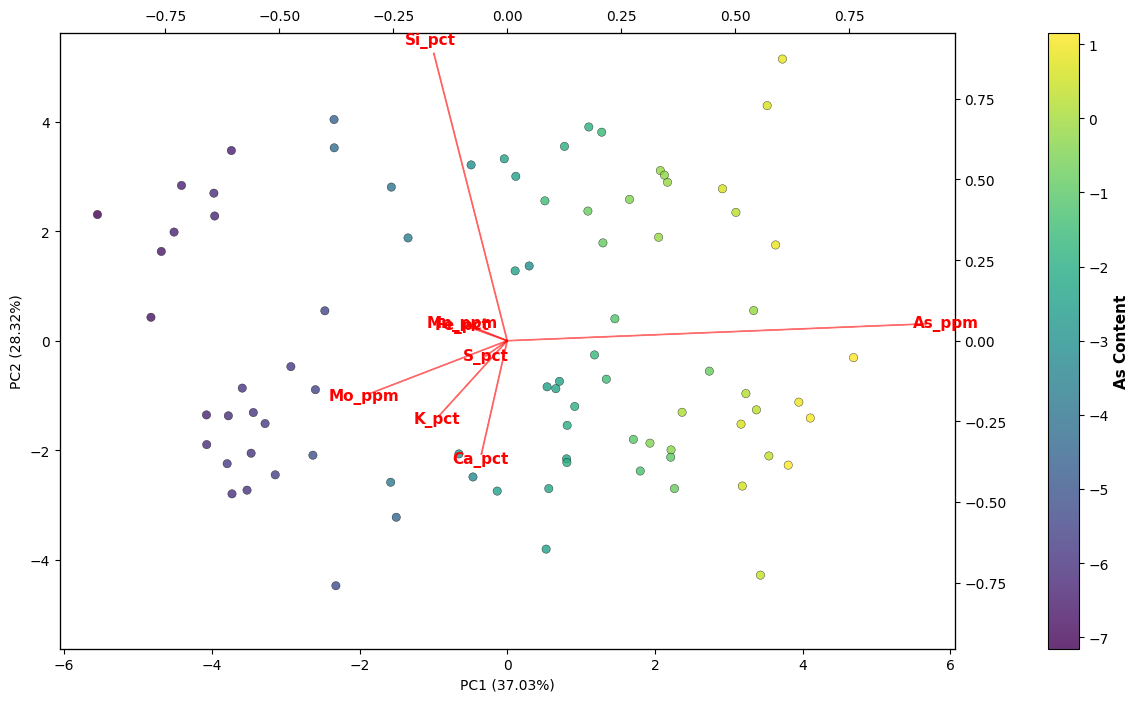

In [9]:
fig, ax, ax2 = biplot(dfScores, components_df, exp_var=pca.explained_variance_ratio_)
plt.savefig("PCA_BP_cc_Si.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Reading the biplot

- **PC1 (≈37% of variance)** and **PC2 (≈28% of variance)** together explain roughly two-thirds of the
  total variance in the CLR-transformed element data.
- Samples plotting toward the **right** side of PC1 have higher CLR-transformed **As** (and are also
  coloured yellow/green on the arsenic colour scale) — the `As_ppm` loading vector points strongly along
  PC1, so PC1 is largely an "arsenic-enrichment" axis.
- The `Si_pct` loading vector points in a very different direction (mostly along PC2), while `S_pct`,
  `Mo_ppm`, `K_pct`, and `Ca_pct` cluster together pointing in a third, roughly opposite direction to `Si`
  indicating those elements (in CLR space) tend to co-vary with each other and inversely with silicon.
  PC2 is interpreted as the host-lithology. With high (or low) As not controlled strictly the Calcic-Silicic lithologies.
- Because the vectors and scores are both derived from CLR-transformed (log-ratio) values, distances and
  angles between vectors approximate compositional relationships (log-ratios) between elements, not their
  raw abundances.
